## ANN for classification, example 1, mobile phone price class classification

**THIS VERSION ATTEMPTS SOME BASIC OPTIMIZATIONS by choosing most relevant variables**

In [25]:
# pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics

# pip install tensorflow
import tensorflow as tf
import keras
from keras import layers

# encoders
from sklearn.preprocessing import LabelEncoder

# classification metrics
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

In [26]:
# load the data
df = pd.read_csv("mobilepricerangeclass.csv")

In [27]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.20,0,1,0,7,0.60,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.50,1,0,1,53,0.70,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.50,1,2,1,41,0.90,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.50,0,0,0,10,0.80,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.20,0,13,1,44,0.60,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [28]:
# check the distribution, completely even distribution (uniform)
df['price_range'].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

In [29]:
# correlation matrix sorted against the target variable
corr_matrix = df.corr()['price_range']
corr_matrix.sort_values(ascending=False)

price_range      1.00
ram              0.92
battery_power    0.20
px_width         0.17
px_height        0.15
int_memory       0.04
sc_w             0.04
pc               0.03
three_g          0.02
sc_h             0.02
fc               0.02
talk_time        0.02
blue             0.02
wifi             0.02
dual_sim         0.02
four_g           0.01
n_cores          0.00
m_dep            0.00
clock_speed     -0.01
mobile_wt       -0.03
touch_screen    -0.03
Name: price_range, dtype: float64

In [30]:
# let's remove some of the variables that are probably not extremely important in this dataset
# NOTE! this was just a quick decision to try optimization, this is just an example
# on how you can use correlation matrix, SelectKBest etc. to choose your variables
removables = ['touch_screen', 'dual_sim', "clock_speed", "m_dep", "three_g", "four_g", "wifi", "blue"]
df = df.drop(removables, axis=1)

In [31]:
# this is technically completely optional
# but it's nicer to study the results when we have actual names for the output
# instead of just 0, 1, 2, 3 etc.

# let's assign actual names for the price classes
# so we have nicer metrics and results later (after training the model)
df['price_range'] = df['price_range'].replace({
    0: "1: Cheap",
    1: "2: Avg-",
    2: "3: Avg+",
    3: "4: Expensive"
})

In [32]:
df.head()

,battery_power,fc,int_memory,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,price_range
0,842,1,7,188,2,2,20,756,2549,9,7,19,2: Avg-
1,1021,0,53,136,3,6,905,1988,2631,17,3,7,3: Avg+
2,563,2,41,145,5,6,1263,1716,2603,11,2,9,3: Avg+
3,615,0,10,131,6,9,1216,1786,2769,16,8,11,3: Avg+
4,1821,13,44,141,2,14,1208,1212,1411,8,2,15,2: Avg-


## X/y -split

**NOTE! Due to cross entropy, we have to modify the y-variable further! See details below**

In [33]:
# perform X/y -split
# if you more than one independent variable, list them all here
# leave out the target variable (dependent variable)

# this is a nice and common trick => everything EXCEPT the target variable => support variables
X = df.drop("price_range", axis=1)

# have only the target variable here (dependent variable)
y_temp = df['price_range']

# since we are doing classification, we have to process our target values with an encoder
# and convert them into a categorical TensorFlow/Keras -format
le = LabelEncoder()
y_enc = le.fit_transform(y_temp)

# convert the label into matrix form
y = tf.keras.utils.to_categorical(y_enc)

# save the categories into a helper list for later purposes
categories = list(le.classes_)
categories

['1: Cheap', '2: Avg-', '3: Avg+', '4: Expensive']

In [34]:
# compare y_temp and y in order to see how they are different
# y

### Let's also quickly try SelectKBest

In [35]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

# convert all continuous variables to integer,
# and convert all negative numbers to 0
X_cat = X.astype(int)
X_cat = X_cat.clip(lower=0)

# initialize chi2 and SelectKBest
# Note: chi2 -test is a very common test
# in statistics and quantitative analysis
# basically it studies the data whether variables are related
# or independent of each other
chi_2_features = SelectKBest(chi2, k=len(X_cat.columns))

# fit our data to the SelectKBest
best_features = chi_2_features.fit(X_cat,y.astype(int))

# use decimal format in table print later
pd.options.display.float_format = '{:.2f}'.format

# wrap it up, and show the results
# the higher the score, the more effect that column has on price
df_features = pd.DataFrame(best_features.scores_)
df_columns = pd.DataFrame(X_cat.columns)
f_scores = pd.concat([df_columns,df_features],axis=1)
f_scores.columns = ['Features','Score']
f_scores.sort_values(by='Score',ascending=False)

,Features,Score
8,ram,931267.52
6,px_height,17363.57
0,battery_power,14129.87
7,px_width,9810.59
3,mobile_wt,95.97
2,int_memory,89.84
10,sc_w,16.48
11,talk_time,13.24
1,fc,10.14
9,sc_h,9.61


### train/test/validation -split

In [36]:
# in Classic ML, we only had train/test -split
# in deep learning, we usually use validation-data also, for better
# optimization possibilities and better metrics

# unfortunately the scikit-learn's train_test_split doesn't support validation
# set split in itself.

# if you want to split the test set into two for a validation set too, try this trick:

# step 1, split the data into 70% (training data) and 30% (temporary data)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.35)

# step 2, split the temporary data in HALF (0.5) => 15% test and 15% validation
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

### Create the neural network structure

**NOTE: you can use all the same callback features as in regression: ModelCheckpoint, EarlyStop, ReduceLRONPlateau, Dropout-layers etc...**

In [37]:
# create neural network

# save the amount of support variables into a helper variable
# so we don't have to update the input_shape all the time
variable_amount = len(X.columns)

# Define Sequential neural network model
# input shape has to match the amount of SUPPORT VARIABLES
# in other words => amount of columns in X 
# Tip: have at least the same number of nodes as in the input shape

# output layer in classification depends on the amounts of
# unique output options in the target variable
model = keras.Sequential(
    [
        layers.BatchNormalization(input_shape=(variable_amount,)),
        layers.Dense(16, activation="relu", kernel_regularizer=keras.regularizers.l1(l1=0.1)),
        layers.Dense(8, activation="relu"),
        layers.Dense(len(categories), activation="softmax")
    ]
)

# select the optimizer and loss function
# for classification, we use categorical crossentropy this time for loss-function
# we also wish to measure the accuracy of our model in the metrics
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

c:\Users\tuomas.valtanen\deeplearning2026lectures\DeepLearningAutumn2026\.venv\Lib\site-packages\keras\src\layers\normalization\batch_normalization.py:181: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_1           │ (None, 12)             │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 428 (1.67 KB)

 Trainable params: 404 (1.58 KB)

 Non-trainable params: 24 (96.00 B)

**Train the next**

In [38]:
# train/fit neural network with validation data
# see the instructions on the train/test -split above on how to split the data correctly
model.fit(x=X_train, y=y_train, epochs=300, validation_data=(X_val, y_val))

Epoch 1/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2846 - loss: 5.4876 - val_accuracy: 0.2114 - val_loss: 5.4666
Epoch 2/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3077 - loss: 4.7488 - val_accuracy: 0.2314 - val_loss: 4.4918
Epoch 3/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3500 - loss: 4.0915 - val_accuracy: 0.3286 - val_loss: 3.8144
Epoch 4/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3900 - loss: 3.5054 - val_accuracy: 0.4457 - val_loss: 3.2434
Epoch 5/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4308 - loss: 2.9685 - val_accuracy: 0.4800 - val_loss: 2.7202
Epoch 6/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4485 - loss: 2.4854 - val_accuracy: 0.4943 - val_loss: 2.2707
Epoch 7/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4838 - loss: 2.0778 - val_accuracy: 0.4886 - val_loss: 1.8971
Epoch 8/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4977 - loss: 1.7515 - val_accuracy: 0.5057 - v

### Error and performance metrics

<Axes: >

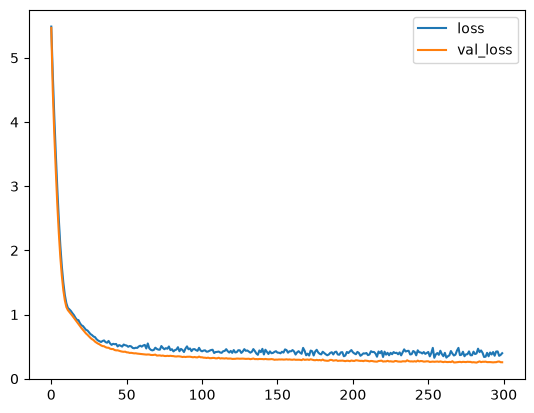

In [39]:
loss_df = pd.DataFrame(model.history.history)
loss_df[['loss', 'val_loss']].plot()

# the model seems to learn fairly well according to loos
# not overfitting, but there's a slight room for improvement

<Axes: >

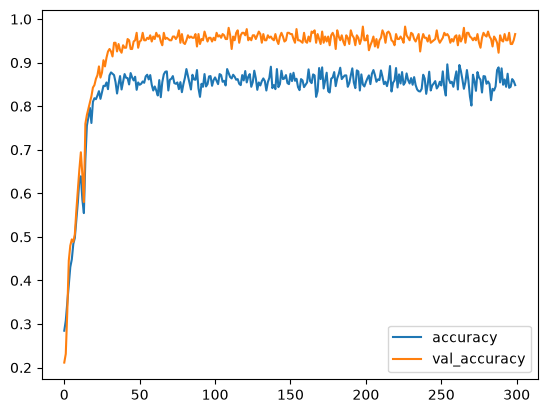

In [40]:
# validation accuracy is fairly high (which is the result from the validation dataset)
# training accuracy is a bit low, but val_accuracy is usually more important to be maximized
# training accuracy being low can imply there's toom for improvement still in the neural network
loss_df[['accuracy', 'val_accuracy']].plot()

In [41]:
# compare the final model loss/evaluation values
# the values should match roughly
print("Test data evaluation:")
print(model.evaluate(X_test, y_test, verbose=0))
print("\nTrain data evaluation:")
print(model.evaluate(X_train, y_train, verbose=0))

# in classification we compare the loss and accuracy values

Test data evaluation:
[0.2521028518676758, 0.9714285731315613]

Train data evaluation:
[0.24806927144527435, 0.9592307806015015]


In [42]:
# get predictions and convert with argmax() to get the categories
# instead of RAW probabilites
test_predictions = model.predict(X_test)
test_predictions = np.argmax(test_predictions, axis=1)

# convert also y-test values with argmax
y_test = np.argmax(y_test, axis=1)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


<Axes: >

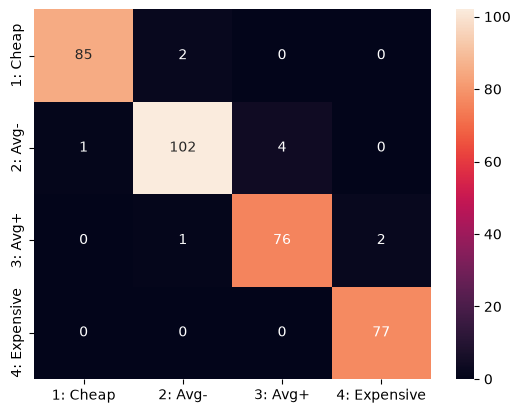

In [43]:
# confusion matrix
sns.heatmap(confusion_matrix(y_test, test_predictions), annot=True, fmt='g',
            xticklabels=categories, yticklabels=categories)

In [44]:
# print the classification report based on true values and predictions
print(classification_report(y_test, test_predictions, target_names=categories))

# get overall accuracy of the model and print it
acc = accuracy_score(y_test, test_predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

    1: Cheap       0.99      0.98      0.98        87
     2: Avg-       0.97      0.95      0.96       107
     3: Avg+       0.95      0.96      0.96        79
4: Expensive       0.97      1.00      0.99        77

    accuracy                           0.97       350
   macro avg       0.97      0.97      0.97       350
weighted avg       0.97      0.97      0.97       350


Model overall accuracy: 97.14%


In [45]:
# The AUC score is a super sensitive metric
# you often get low scores, even 0.5

# in binary classification, AUC values are often interpreted as follows:
# A binary classifier is useful only when it achieves ROC-AUC score greater than 0.5 and as near to 1 as possible. 
# If a classifier yields a score less than 0.5, it simply means that the model is performing worse 
# than a random classifier, and therefore is useless.

# In multi category classification , AUC values are often interpreted as follows: 
# 0.5-0.6 (failed)
# 0.6-0.7 (worthless)
# 0.7-0.8 (poor)
# 0.8-0.9 (good)
# > 0.9 (excellent)

# get ROC-AUC -score
roc_auc_score(y, model.predict(X), multi_class="ovr")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 680us/step


0.9984173333333334

### Try the model in practice with new data

In [46]:
X.columns

Index(['battery_power', 'fc', 'int_memory', 'mobile_wt', 'n_cores', 'pc',
       'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time'],
      dtype='str')

In [47]:
df.head(3)

,battery_power,fc,int_memory,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,price_range
0,842,1,7,188,2,2,20,756,2549,9,7,19,2: Avg-
1,1021,0,53,136,3,6,905,1988,2631,17,3,7,3: Avg+
2,563,2,41,145,5,6,1263,1716,2603,11,2,9,3: Avg+


In [49]:
# let's try with some imaginary data
# modify this as needed regarding your own dataset

tester_row = {
    'battery_power': 1021, 
    'fc': 0, 
    'int_memory': 53, 
    'mobile_wt': 136, 
    'n_cores': 3, 
    'pc': 6,
    'px_height': 905, 
    'px_width': 1988, 
    'ram': 3031, 
    'sc_h': 17, 
    'sc_w': 3, 
    'talk_time': 7 
}

# convert to pandas-format
tester_row = pd.DataFrame([tester_row])
result = model.predict(tester_row)[0]
result_text = categories[np.argmax(result)]

# switch to decimal representation 
np.set_printoptions(precision=9, suppress=True)

# 0 cheapest, 3 most expensive
print(f"Predicted price range: {result_text}")
print()
print("Probabilities by class:")
print(categories)
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicted price range: 4: Expensive

Probabilities by class:
['1: Cheap', '2: Avg-', '3: Avg+', '4: Expensive']
[0.000000044 0.000161145 0.08549142  0.9143475  ]
